<h1 align="center">ใบงานที่ 3 Regression & Classification</h1>

## LAB 2: Classification

### Preparing Classification Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load dataset
df = pd.read_csv('Dataset.csv')

# Create Binary Target Column: Has_Devil_Fruit (1 = Has Fruit, 0 = No Fruit)
df_clf = df.copy()
df_clf['Has_Devil_Fruit'] = df_clf['Devil_Fruit'].notnull().astype(int)

# Select Features (X) and Target (y)
X = df_clf[['Height_cm', 'Age']]
y = df_clf['Has_Devil_Fruit']

# Train-Test Split (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Classification Dataset Overview ===")
print("Target Class Counts (Has_Devil_Fruit):")
print(df_clf['Has_Devil_Fruit'].value_counts().rename(index={1: 'Has Devil Fruit', 0: 'No Devil Fruit'}))
print("\nTraining set size:", len(X_train))
print("Testing set size:", len(X_test))

=== Classification Dataset Overview ===
Target Class Counts (Has_Devil_Fruit):
Has_Devil_Fruit
Has Devil Fruit    26
No Devil Fruit     12
Name: count, dtype: int64

Training set size: 30
Testing set size: 8


<div style="padding: 12px; background-color: #0f1c20; border-left: 5px solid #ff0000; border-radius: 4px; color: #00ff88;">
  <strong> Note:</strong> Load dataset from CSV (Dataset_One Piece)
</div>

### Logistic Regression Training & Evaluation

In [ ]:
# Initialize and train Logistic Regression model
clf_model = LogisticRegression(class_weight='balanced', random_state=42)
clf_model.fit(X_train, y_train)

# Predict on Test Set
y_pred = clf_model.predict(X_test)

# Display Performance Metrics
print("\n=== Logistic Regression Results ===")
print(f"model Intercept (B0): {clf_model.intercept_[0]:.4f}")
print(f"Coefficient for Height_cm (B1): {clf_model.coef_[0][0]:.4f}")
print(f"Coefficient for Age (B2): {clf_model.coef_[0][1]:.4f}")
print("-" * 50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,zero_division=0, target_names=['No Devil Fruit', 'Has Devil Fruit']))


=== Logistic Regression Results ===
model Intercept (B0): -1.1020
Coefficient for Height_cm (B1): 0.0099
Coefficient for Age (B2): -0.0373
--------------------------------------------------
Accuracy Score: 0.7500

Classification Report:
                 precision    recall  f1-score   support

 No Devil Fruit       0.60      1.00      0.75         3
Has Devil Fruit       1.00      0.60      0.75         5

       accuracy                           0.75         8
      macro avg       0.80      0.80      0.75         8
   weighted avg       0.85      0.75      0.75         8



### Confusion Matrix Visualization

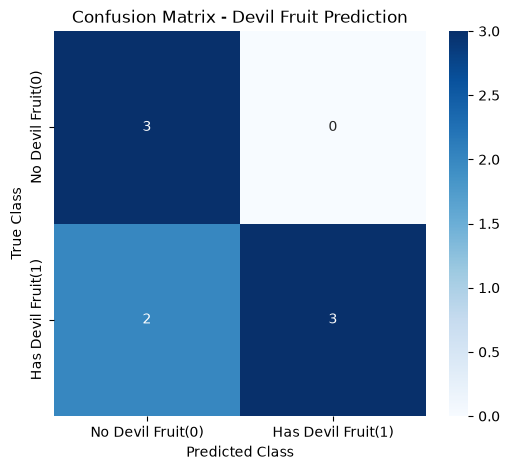

In [ ]:
# Compute Confusion Matrix
cm =confusion_matrix(y_test, y_pred)

# Plot Heatmap using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Devil Fruit(0)', 'Has Devil Fruit(1)'],
            yticklabels=['No Devil Fruit(0)', 'Has Devil Fruit(1)'])
plt.title('Confusion Matrix - Devil Fruit Prediction')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

### Decision Boundary Visualization

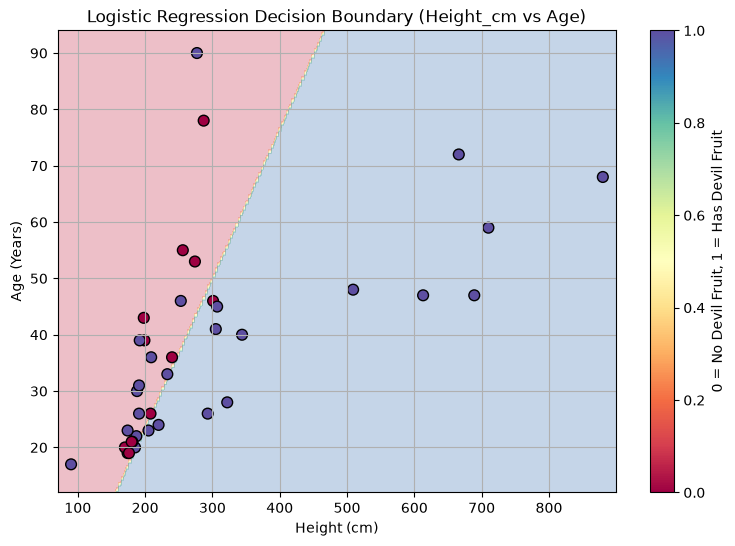

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a grid of points for plotting decision boundary
x_min, x_max = X['Height_cm'].min() - 20, X['Height_cm'].max() + 20
y_min, y_max = X['Age'].min() - 5, X['Age'].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 1), np.arange(y_min, y_max, 1))

# Convert grid array to DataFrame with feature names to prevent sklearn warnings
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['Height_cm', 'Age'])

# Predict outcome for each point on the grid
Z = clf_model.predict(grid_df)
Z = Z.reshape(xx.shape)

# Plot Decision Boundary and Scatter Plot
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Spectral)

# Scatter plot of actual data points
scatter = plt.scatter(
    X['Height_cm'], 
    X['Age'], 
    c=y, 
    edgecolors='k', 
    cmap=plt.cm.Spectral, 
    s=60
)

plt.title('Logistic Regression Decision Boundary (Height_cm vs Age)')
plt.xlabel('Height (cm)')
plt.ylabel('Age (Years)')
plt.colorbar(scatter, label='0 = No Devil Fruit, 1 = Has Devil Fruit')
plt.grid(True)
plt.show()

### Prediction Inference on New Character

In [13]:
# Input values for a new chacracter
input_height = 180
input_age = 25

# Create a DataFrame for prediction
new_character_df = pd.DataFrame({
    'Height_cm': [input_height],
    'Age': [input_age]
})

# predict Class and Probability
predicted_class = clf_model.predict(new_character_df)[0]
predicted_proba = clf_model.predict_proba(new_character_df)[0]

#Display dynamic results
status_str = "Has Devil Fruit 🍎" if predicted_class == 1 else "No Devil Fruit ⚔️"

print("=== Prediction for New Character ===")
print(f"Character Input: Height = {new_character_df['Height_cm'][0]} cm | Age = {new_character_df['Age'][0]} years")
print(f"Predicted Class: {predicted_class} ({status_str})")
print(f"Probability (No Devil Fruit): {predicted_proba[0]*100:.2f}")
print(f"Probability (Has Devil Fruit): {predicted_proba[1]*100:.2f}")

=== Prediction for New Character ===
Character Input: Height = 180 cm | Age = 25 years
Predicted Class: 0 (No Devil Fruit ⚔️)
Probability (No Devil Fruit): 56.37
Probability (Has Devil Fruit): 43.63
